<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c7_ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use t-SNE to reduce the first 5,000 images of the MNIST dataset down to two dimensions and plot the result using Matplotlib. You can use a scatterplot using 10 different colors to represent each image's target class.

In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
mnist = fetch_openml('mnist_784', as_frame = False)

X,y = mnist.data, mnist.target

X_sample, y_sample = X[:5000], y[:5000]

X_sample.shape


(5000, 784)

In [3]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, learning_rate='auto', init='random')
X_reduced = tsne.fit_transform(X_sample)

In [4]:
X_reduced.shape

(5000, 2)

Now that we have reduced the data down to two dimensions, let's plot it.
Recall that each instance had dimension 784.

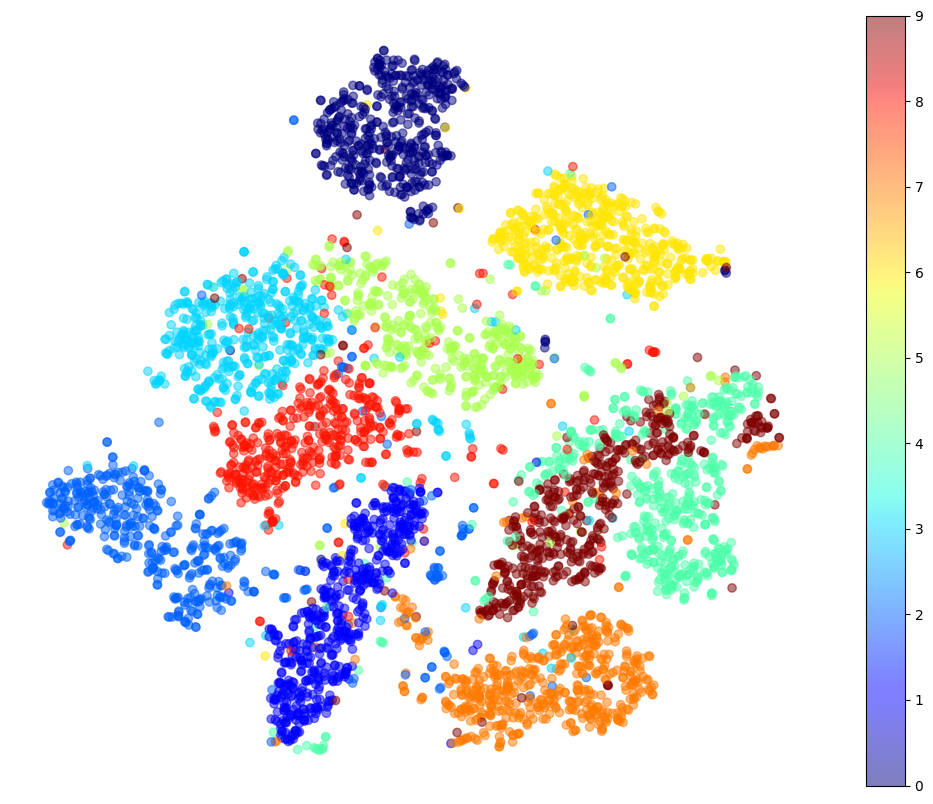

In [5]:
from matplotlib import pyplot as plt
plt.figure(figsize=(13,10))
## X_reduced has 2 dimensions, here we plot them as (first coordinate, second coordinate)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()

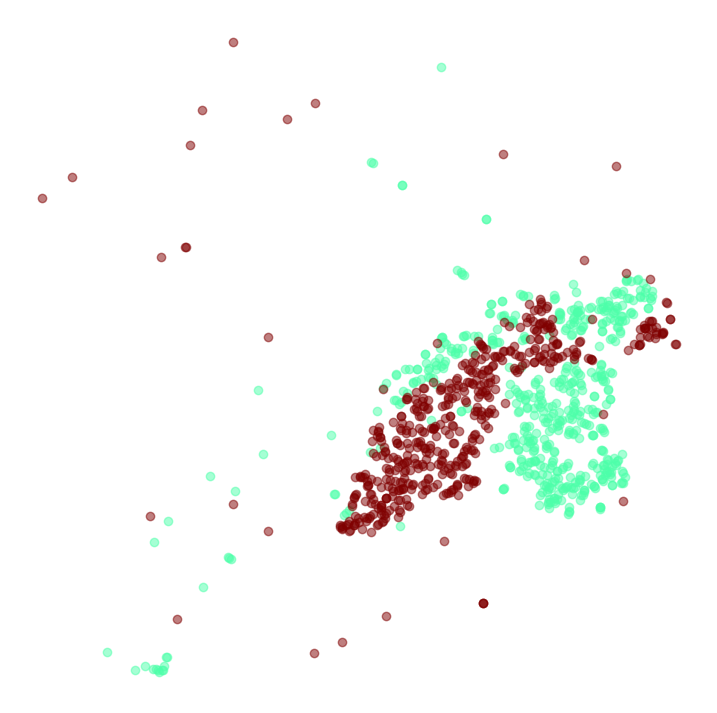

In [13]:
# this is a zoom on the digits 4 and 9 that overlap significantly
plt.figure(figsize=(9, 9))
cmap = plt.cm.jet
for digit in ('4', '9'):
    plt.scatter(X_reduced[y_sample == digit, 0], X_reduced[y_sample == digit, 1],
                c=[cmap(float(digit) / 9)], alpha=0.5)
plt.axis('off')
plt.show()

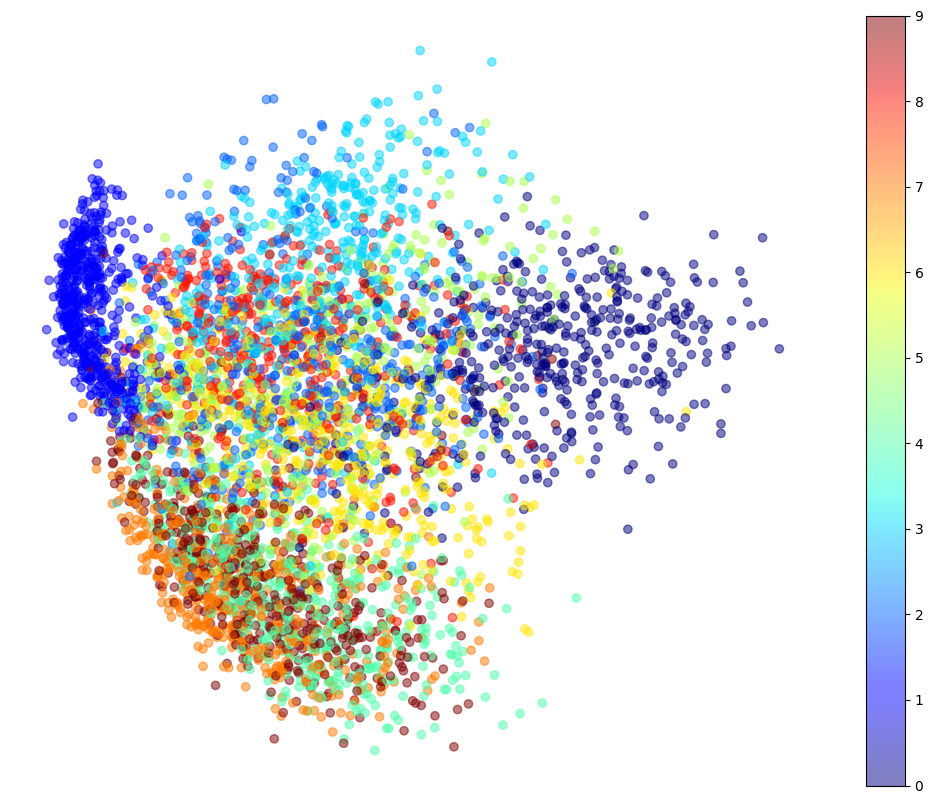

In [8]:
# Let's try to visualize PCA reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(13,10))
plt.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()

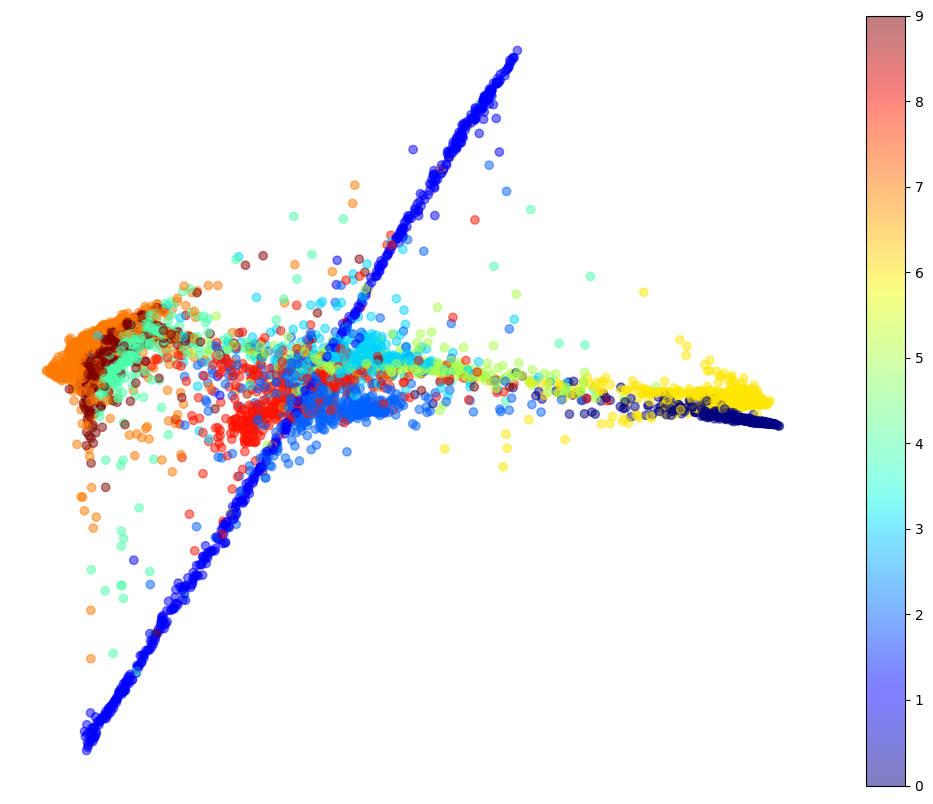

In [14]:
# LLE (locally linear embeddings)
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_reduced_lle = lle.fit_transform(X_sample)

plt.figure(figsize=(13,10))
plt.scatter(X_reduced_lle[:, 0], X_reduced_lle[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()

Let's see what happens if we apply PCA first, preserving 95% of the variance:

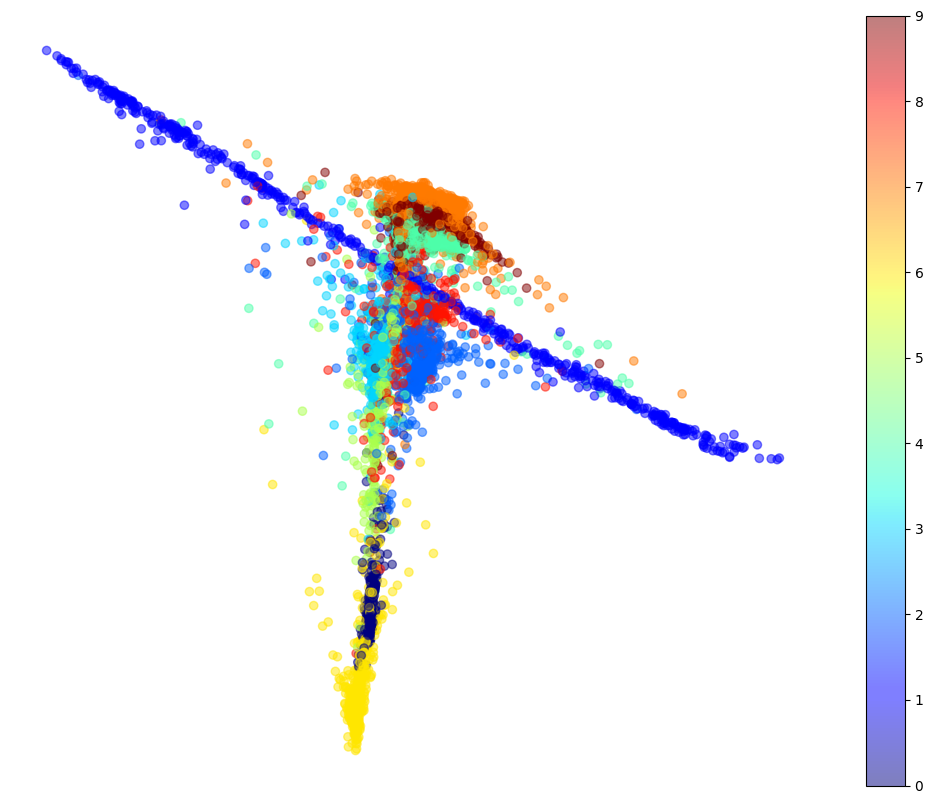

In [15]:
from sklearn.pipeline import make_pipeline

pca_lle = make_pipeline(PCA(n_components=0.95, random_state=42),
                        LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42))

X_reduced_pca_lle = pca_lle.fit_transform(X_sample)

plt.figure(figsize=(13,10))
plt.scatter(X_reduced_pca_lle[:, 0], X_reduced_pca_lle[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()